# Sampling Methods for Probability Distributions

This notebook surveys the major families of sampling algorithms used in probabilistic machine learning and Bayesian inference. When the target distribution $p(z)$ is complex — known only up to a normalizing constant, or lacking a closed-form sampler — we rely on these techniques to generate draws that approximate $p(z)$.

**Methods covered:**

| # | Method | Key Idea |
|---|---|---|
| 1 | **Importance Sampling** (single Gaussian) | Re-weight samples from a simple proposal |
| 2 | **Importance Sampling** (mixture proposal) | Better proposal coverage for multimodal targets |
| 3 | **Metropolis–Hastings** | Random-walk MCMC with accept/reject |
| 4 | **Gibbs Sampling** | Alternate sampling from conditional distributions |
| 5 | **Metropolis-within-Gibbs** | Hybrid: Gibbs for tractable conditionals, MH for the rest |
| 6 | **Ancestral Sampling** | Forward sampling through a directed graphical model |
| 7 | **Langevin Dynamics** | Gradient-based MCMC using the score function |

In [3]:
import numpy as np
print("NumPy version:", np.__version__)

NumPy version: 2.4.2


In [29]:
import numpy as np

# import numpy as np
print(np.__version__)

2.4.2


## 1. Importance Sampling (Single Gaussian Proposal)

**Importance Sampling** lets us estimate expectations under a target distribution $p(z)$ *without* sampling from it directly. Instead, we sample from a simpler **proposal distribution** $q(z)$ and correct via re-weighting.

### Algorithm

Given an unnormalized target $\tilde{p}(z)$ and a proposal $q(z)$:

1. Draw $L$ samples $z^{(1)}, \ldots, z^{(L)} \sim q(z)$.
2. Compute **unnormalized importance weights**: $\tilde{r}^{(\ell)} = \dfrac{\tilde{p}(z^{(\ell)})}{q(z^{(\ell)})}$
3. **Normalize** the weights: $w^{(\ell)} = \dfrac{\tilde{r}^{(\ell)}}{\sum_{j=1}^L \tilde{r}^{(j)}}$
4. Estimate the expectation: $\hat{E}_p[f(z)] = \sum_{\ell=1}^L w^{(\ell)}\, f(z^{(\ell)})$

### Setup

| Component | Definition |
|---|---|
| Unnormalized target | $\tilde{p}(z) = \exp(-z^4 + 2z^2)$ — bimodal with peaks near $z = \pm 1$ |
| Proposal | $q(z) = \mathcal{N}(0, 4)$ — a single wide Gaussian ($\sigma = 2$) |
| Function of interest | $f(z) = z^2$ |
| Number of samples | $L = 100{,}000$ |

### Why It Works

The key identity is:

$$E_p[f(z)] = \int f(z)\,p(z)\,dz = \int f(z)\,\frac{p(z)}{q(z)}\,q(z)\,dz = E_q\!\left[f(z)\,\frac{p(z)}{q(z)}\right]$$

When $p$ is known only up to a constant, the self-normalized variant (step 3 above) avoids needing $Z_p$.

### Limitation of a Single Gaussian Proposal

A single Gaussian centred at $0$ may not cover both modes of the bimodal target well, leading to high-variance weights. The next cell pair addresses this with a **mixture proposal**.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Unnormalized target density
# ----------------------------
def p_tilde(z):
    return np.exp(-z**4 + 2*z**2)

# ----------------------------
# Proposal density q(z)
# Gaussian N(0, sigma^2)
# ----------------------------
sigma = 2.0

def q_tilde(z):
    # unnormalized Gaussian
    return np.exp(-0.5 * (z / sigma)**2)

# ----------------------------
# Function whose expectation we want
# ----------------------------
def f(z):
    return z**2

# ----------------------------
# Importance Sampling
# ----------------------------
np.random.seed(0)
L = 100_000

# Step 1: sample from q(z)
z_samples = np.random.normal(0, sigma, size=L)

# Step 2: compute unnormalized importance weights
r_tilde = p_tilde(z_samples) / q_tilde(z_samples)

# Step 3: normalize weights
weights = r_tilde / np.sum(r_tilde)

# Step 4: estimate expectation
E_f = np.sum(weights * f(z_samples))

print("Estimated E_p[z^2] =", E_f)


Estimated E_p[z^2] = 0.8312534287099436


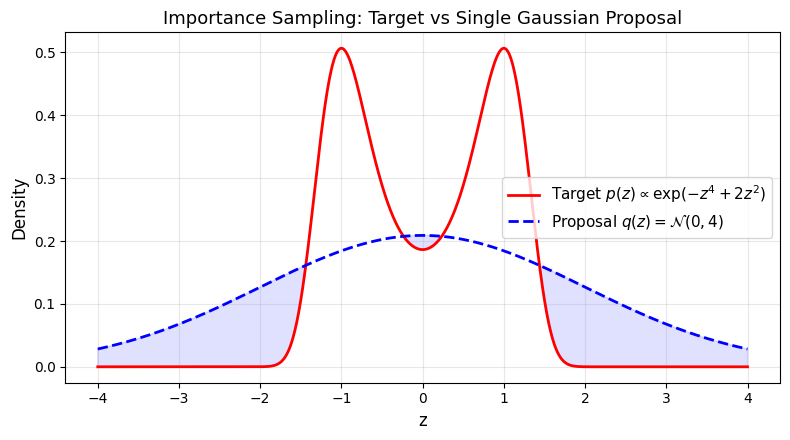

Saved to images/is_single_gaussian_target_vs_proposal.png


In [44]:
# Plot target and proposal (scaled)
z = np.linspace(-4, 4, 1000)

p_vals = p_tilde(z)
p_vals /= np.trapezoid(p_vals, z)   # normalize for visualization

q_vals = np.exp(-0.5 * (z / sigma)**2)
q_vals /= np.trapezoid(q_vals, z)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z, p_vals, 'r', lw=2, label=r"Target $p(z) \propto \exp(-z^4 + 2z^2)$")
ax.plot(z, q_vals, 'b--', lw=2, label=r"Proposal $q(z) = \mathcal{N}(0, 4)$")
ax.fill_between(z, p_vals, q_vals, where=(q_vals > p_vals), alpha=0.12, color='blue')
ax.set_xlabel("z", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Importance Sampling: Target vs Single Gaussian Proposal", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("images/is_single_gaussian_target_vs_proposal.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/is_single_gaussian_target_vs_proposal.png")

## 2. Importance Sampling (Mixture Proposal)

To fix the poor coverage of a single Gaussian, we use a **Gaussian mixture** as the proposal:

$$q(z) = \pi_1\,\mathcal{N}(z \mid \mu_1, \sigma_1^2) + \pi_2\,\mathcal{N}(z \mid \mu_2, \sigma_2^2)$$

### Setup

| Parameter | Value | Purpose |
|---|---|---|
| $\pi_1, \pi_2$ | 0.5, 0.5 | Equal mixture weights |
| $\mu_1, \mu_2$ | $-1.0,\; 1.0$ | Centres placed near the two target modes |
| $\sigma_1, \sigma_2$ | 0.5, 0.5 | Narrow enough to concentrate mass on each mode |

### Why a Mixture Helps

The bimodal target $\tilde{p}(z) = \exp(-z^4 + 2z^2)$ has two peaks near $z = \pm 1$. A **single** Gaussian centred at $0$ wastes probability mass in the valley between the modes, producing a few samples with very large weights and many with near-zero weights — this inflates variance.

A **mixture** that places one component on each mode keeps $q(z) / \tilde{p}(z)$ more uniform, resulting in lower-variance weight estimates and a more reliable $\hat{E}_p[f(z)]$.

### Effective Sample Size (ESS)

A useful diagnostic for importance sampling quality is the **effective sample size**:

$$\text{ESS} = \frac{1}{\sum_{\ell=1}^L (w^{(\ell)})^2}$$

An ESS close to $L$ indicates uniform weights (good); an ESS close to $1$ means a single sample dominates (bad).

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Target (unnormalized)
# ----------------------------
def p_tilde(z):
    return np.exp(-z**4 + 2*z**2)

# ----------------------------
# Mixture proposal parameters
# ----------------------------
pi = np.array([0.5, 0.5])
mu = np.array([-1.0, 1.0])
sigma = np.array([0.5, 0.5])

# ----------------------------
# Gaussian PDF
# ----------------------------
def gaussian_pdf(z, mu, sigma):
    return (1 / (np.sqrt(2*np.pi) * sigma)) * \
           np.exp(-0.5 * ((z - mu) / sigma)**2)

# ----------------------------
# Mixture density q(z)
# ----------------------------
def q_pdf(z):
    return (pi[0] * gaussian_pdf(z, mu[0], sigma[0]) +
            pi[1] * gaussian_pdf(z, mu[1], sigma[1]))

# ----------------------------
# Sample from mixture
# ----------------------------
def sample_q(L):
    components = np.random.choice([0, 1], size=L, p=pi)
    z = np.zeros(L)
    for k in [0, 1]:
        idx = components == k
        z[idx] = np.random.normal(mu[k], sigma[k], np.sum(idx))
    return z

# ----------------------------
# Function to estimate
# ----------------------------
def f(z):
    return z**2

# ----------------------------
# Importance sampling
# ----------------------------
np.random.seed(42)
L = 100_000

z_samples = sample_q(L)
r_tilde = p_tilde(z_samples) / q_pdf(z_samples)
weights = r_tilde / np.sum(r_tilde)

E_f = np.sum(weights * f(z_samples))
print("Estimated E_p[z^2] =", E_f)


Estimated E_p[z^2] = 0.8325154777131765


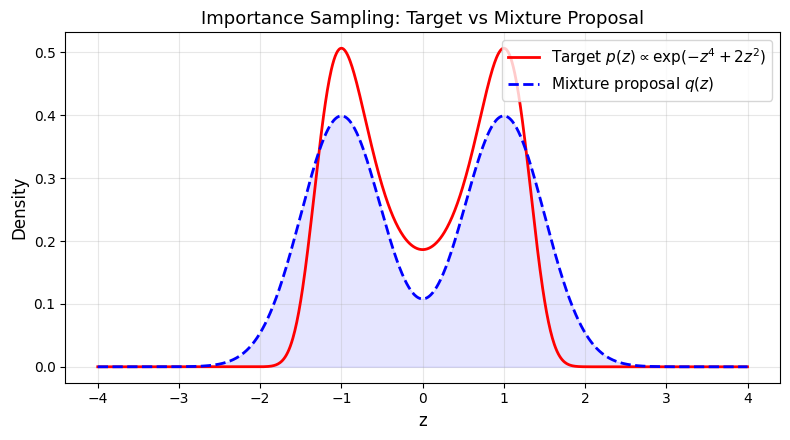

Saved to images/is_mixture_target_vs_proposal.png


In [46]:
# Plot target and mixture proposal (scaled)
z = np.linspace(-4, 4, 1000)

p_vals = p_tilde(z)
p_vals /= np.trapezoid(p_vals, z)   # normalize for visualization

q_vals = q_pdf(z)
q_vals /= np.trapezoid(q_vals, z)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(z, p_vals, 'r', lw=2, label=r"Target $p(z) \propto \exp(-z^4 + 2z^2)$")
ax.plot(z, q_vals, 'b--', lw=2, label=r"Mixture proposal $q(z)$")
ax.fill_between(z, 0, q_vals, alpha=0.10, color='blue')
ax.set_xlabel("z", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Importance Sampling: Target vs Mixture Proposal", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("images/is_mixture_target_vs_proposal.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/is_mixture_target_vs_proposal.png")

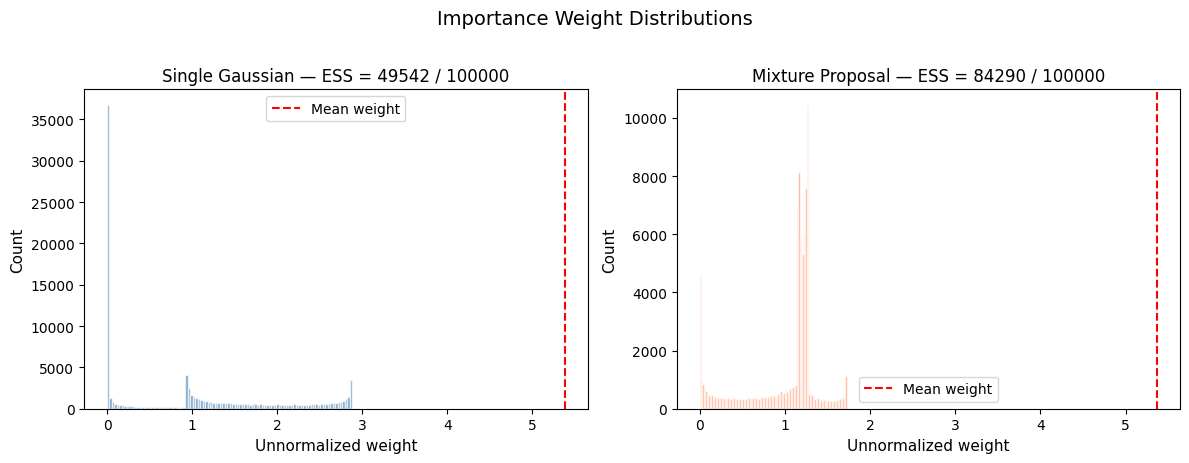

Single Gaussian — ESS: 49542 / 100000
Mixture Proposal — ESS: 84290 / 100000
Single Gaussian — E_p[z^2] = 0.8313
Mixture Proposal — E_p[z^2] = 0.8325
Saved to images/is_weight_comparison.png


In [47]:
# Compare weight distributions and compute ESS for both proposals
# --- Single Gaussian weights (recompute) ---
sigma_single = 2.0
def q_single(z):
    return (1 / (np.sqrt(2*np.pi) * sigma_single)) * np.exp(-0.5 * (z / sigma_single)**2)

np.random.seed(0)
z_single = np.random.normal(0, sigma_single, size=L)
r_single = p_tilde(z_single) / q_single(z_single)
w_single = r_single / np.sum(r_single)
ess_single = 1.0 / np.sum(w_single**2)

# --- Mixture weights (already computed) ---
ess_mixture = 1.0 / np.sum(weights**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(w_single * L, bins=100, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].set_title(f"Single Gaussian — ESS = {ess_single:.0f} / {L}", fontsize=12)
axes[0].set_xlabel("Unnormalized weight", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].axvline(np.mean(r_single), color='red', ls='--', lw=1.5, label="Mean weight")
axes[0].legend()

axes[1].hist(weights * L, bins=100, alpha=0.7, color='coral', edgecolor='white')
axes[1].set_title(f"Mixture Proposal — ESS = {ess_mixture:.0f} / {L}", fontsize=12)
axes[1].set_xlabel("Unnormalized weight", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].axvline(np.mean(r_tilde), color='red', ls='--', lw=1.5, label="Mean weight")
axes[1].legend()

fig.suptitle("Importance Weight Distributions", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("images/is_weight_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Single Gaussian — ESS: {ess_single:.0f} / {L}")
print(f"Mixture Proposal — ESS: {ess_mixture:.0f} / {L}")
print(f"Single Gaussian — E_p[z^2] = {np.sum(w_single * z_single**2):.4f}")
print(f"Mixture Proposal — E_p[z^2] = {E_f:.4f}")
print("Saved to images/is_weight_comparison.png")

## 3. Metropolis–Hastings Sampling

**Metropolis–Hastings (MH)** is a Markov-chain Monte Carlo (MCMC) method that produces a sequence of *correlated* samples whose stationary distribution is the target $p(z)$. Unlike importance sampling, MH does not require a good global proposal — a simple local random-walk suffices.

### Algorithm

1. Initialise $z_0$ (e.g. $z_0 = 0$).
2. For $t = 1, 2, \ldots, T$:
   - **Propose**: $z^* = z_{t-1} + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma_{\text{step}}^2)$.
   - **Accept/reject**: Compute the acceptance ratio

     $$A = \min\!\left(1,\; \frac{\tilde{p}(z^*)}{\tilde{p}(z_{t-1})}\right)$$

   - With probability $A$, set $z_t = z^*$ (accept); otherwise $z_t = z_{t-1}$ (reject).

Because only the *ratio* $\tilde{p}(z^*)/\tilde{p}(z_{t-1})$ appears, the normalizing constant cancels — we only need the unnormalized target.

### Setup

| Component | Definition |
|---|---|
| Unnormalized target | $\tilde{p}(z) = \exp\!\bigl(-\tfrac{1}{8}z^4 + \tfrac{3}{4}z^2 + 1\bigr)$ — bimodal |
| Proposal | Symmetric random walk: $z^* \sim \mathcal{N}(z_{t-1},\, 0.64)$ with step size $0.8$ |
| Chain length | $T = 20{,}000$ |
| Burn-in | First $5{,}000$ samples discarded |

### Key Concepts

- **Burn-in**: Early samples still reflect the initial point, not the target. They are discarded.
- **Detailed balance**: The acceptance rule guarantees $p(z)$ is the unique stationary distribution.
- **Step-size trade-off**: Too small → high acceptance but slow exploration; too large → many rejections. An acceptance rate of ~23%–50% is typically optimal for a 1-D target.

### Visualization

The histogram of accepted samples is overlaid with the true (numerically normalized) density $p(z)$. A close match confirms the chain has converged.

In [2]:
# ---------------------------- Metropolis-Hastings Sampling ----------------------------
import numpy as np
import matplotlib.pyplot as plt
# ----------------------------

def p_tilde(z):
    return np.exp(-0.125 * z**4 + 0.75 * z**2 +1)


In [3]:
def metropolis_sampler(p_tilde, n_samples=20000, step_size=0.8):
    samples = np.zeros(n_samples)
    z = 0.0  # initial state

    for i in range(n_samples):
        # Propose new point
        z_star = z + np.random.normal(0, step_size)

        # Acceptance probability
        acceptance_ratio = p_tilde(z_star) / p_tilde(z)
        A = min(1.0, acceptance_ratio)

        # Accept or reject
        if np.random.rand() < A:
            z = z_star

        samples[i] = z

    return samples

samples = metropolis_sampler(p_tilde)

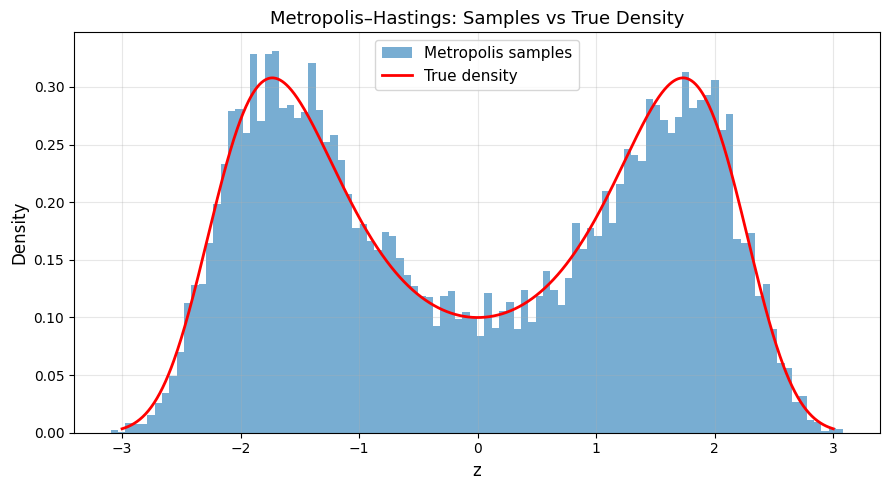

Saved to images/mh_samples_vs_density.png


In [4]:
# Histogram of samples vs true density
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(samples, bins=100, density=True, alpha=0.6, label="Metropolis samples")

# True (unnormalized) density for comparison
z_grid = np.linspace(-3, 3, 1000)
p_vals = p_tilde(z_grid)
p_vals /= np.trapezoid(p_vals, z_grid)

ax.plot(z_grid, p_vals, 'r', lw=2, label="True density")
ax.set_xlabel("z", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Metropolis–Hastings: Samples vs True Density", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("images/mh_samples_vs_density.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/mh_samples_vs_density.png")

Estimated E[z^2]: 2.4407
Acceptance rate: 0.726


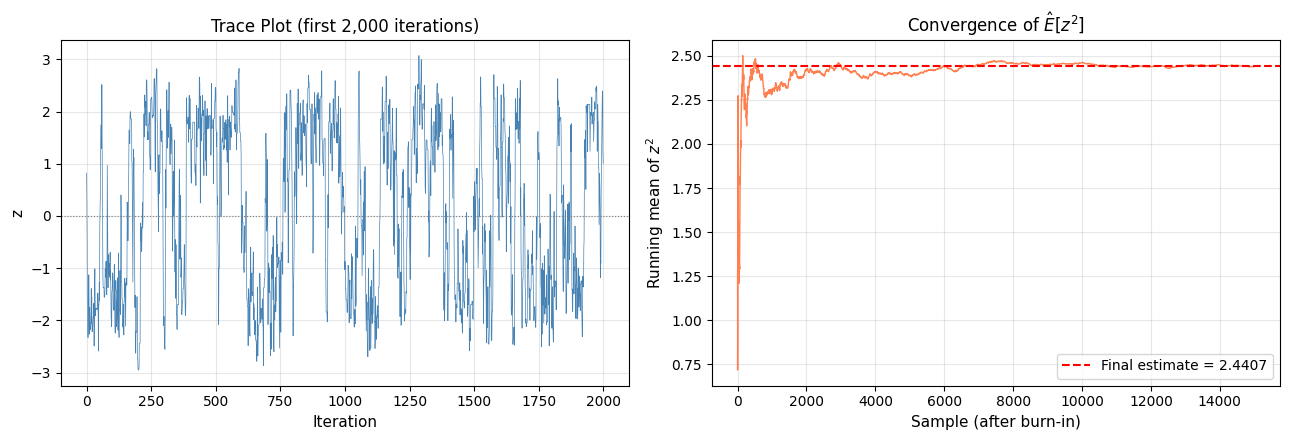

Saved to images/mh_trace_and_convergence.png


In [5]:
# Burn-in removal and trace plot
burn_in = 5000
samples_eff = samples[burn_in:]

# Estimate expectation
Ez2 = np.mean(samples_eff**2)

# Acceptance rate
n_accept = np.sum(np.diff(samples) != 0)
accept_rate = n_accept / (len(samples) - 1)

print(f"Estimated E[z^2]: {Ez2:.4f}")
print(f"Acceptance rate: {accept_rate:.3f}")

# Trace plot + running mean
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: trace plot (first 2000 samples)
axes[0].plot(samples[:2000], lw=0.5, color='steelblue')
axes[0].axhline(0, color='gray', ls=':', lw=0.8)
axes[0].set_xlabel("Iteration", fontsize=11)
axes[0].set_ylabel("z", fontsize=11)
axes[0].set_title("Trace Plot (first 2,000 iterations)", fontsize=12)
axes[0].grid(True, alpha=0.3)

# Right: running mean of z^2 after burn-in
running_mean = np.cumsum(samples_eff**2) / np.arange(1, len(samples_eff) + 1)
axes[1].plot(running_mean, lw=1.0, color='coral')
axes[1].axhline(Ez2, color='red', ls='--', lw=1.5, label=f"Final estimate = {Ez2:.4f}")
axes[1].set_xlabel("Sample (after burn-in)", fontsize=11)
axes[1].set_ylabel(r"Running mean of $z^2$", fontsize=11)
axes[1].set_title(r"Convergence of $\hat{E}[z^2]$", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/mh_trace_and_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/mh_trace_and_convergence.png")

## 4. Gibbs Sampling

**Gibbs Sampling** is an MCMC method for multivariate distributions. Instead of proposing a joint move in all dimensions at once, it samples **one variable at a time** from its conditional distribution, holding the others fixed.

### Algorithm

For a bivariate distribution $p(z_1, z_2)$:

1. Initialise $z_1^{(0)}, z_2^{(0)}$.
2. For $t = 1, 2, \ldots, T$:
   - Sample $z_1^{(t)} \sim p(z_1 \mid z_2^{(t-1)})$
   - Sample $z_2^{(t)} \sim p(z_2 \mid z_1^{(t)})$ ← uses the **updated** $z_1$

Each step is an *exact* draw from the conditional, so there is **no accept/reject** — every sample is accepted.

### Setup: Correlated Bivariate Gaussian

The target is a bivariate Gaussian:

$$\begin{pmatrix} z_1 \\ z_2 \end{pmatrix} \sim \mathcal{N}\!\left(\begin{pmatrix} 0 \\ 0 \end{pmatrix},\; \begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}\right)$$

with correlation $\rho = 0.9$. The conditionals are:

$$z_1 \mid z_2 \sim \mathcal{N}(\rho\, z_2,\; 1 - \rho^2), \qquad z_2 \mid z_1 \sim \mathcal{N}(\rho\, z_1,\; 1 - \rho^2)$$

| Parameter | Value |
|---|---|
| Correlation $\rho$ | 0.9 |
| Conditional std $\sigma_{\text{cond}}$ | $\sqrt{1 - 0.81} \approx 0.436$ |
| Samples | 10,000 |
| Burn-in | 1,000 |

### Key Observations
- **High correlation** ($\rho = 0.9$) means the elliptical cloud is narrow and tilted — Gibbs still works because each conditional is a simple 1-D Gaussian.
- **Slow mixing**: With very high $\rho$ the chain takes small, correlated steps along the narrow direction of the ellipse. For $\rho \to 1$ mixing degrades significantly.
- **No tuning required**: Unlike MH, there is no step size to tune — the conditional distributions dictate the proposal implicitly.

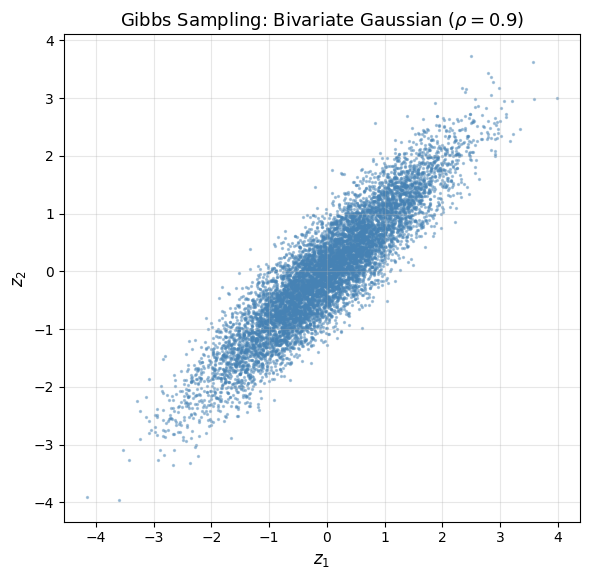

Saved to images/gibbs_joint_scatter.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
rho = 0.9
sigma_cond = np.sqrt(1 - rho**2)

n_samples = 10000

# Storage
z1 = np.zeros(n_samples)
z2 = np.zeros(n_samples)

# Initialization
z1[0] = 0.0
z2[0] = 0.0

# Gibbs sampling loop
for t in range(1, n_samples):
    # Sample z1 | z2  (one variable at a time)
    z1[t] = np.random.normal(loc=rho * z2[t-1], scale=sigma_cond)
    
    # Sample z2 | z1  (use the UPDATED z1!)
    z2[t] = np.random.normal(loc=rho * z1[t], scale=sigma_cond)

burn_in = 1000

# ── Figure 1: Joint scatter plot ──
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(z1[burn_in:], z2[burn_in:], s=2, alpha=0.4, color='steelblue')
ax.set_xlabel(r"$z_1$", fontsize=12)
ax.set_ylabel(r"$z_2$", fontsize=12)
ax.set_title(r"Gibbs Sampling: Bivariate Gaussian ($\rho=0.9$)", fontsize=13)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("images/gibbs_joint_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/gibbs_joint_scatter.png")

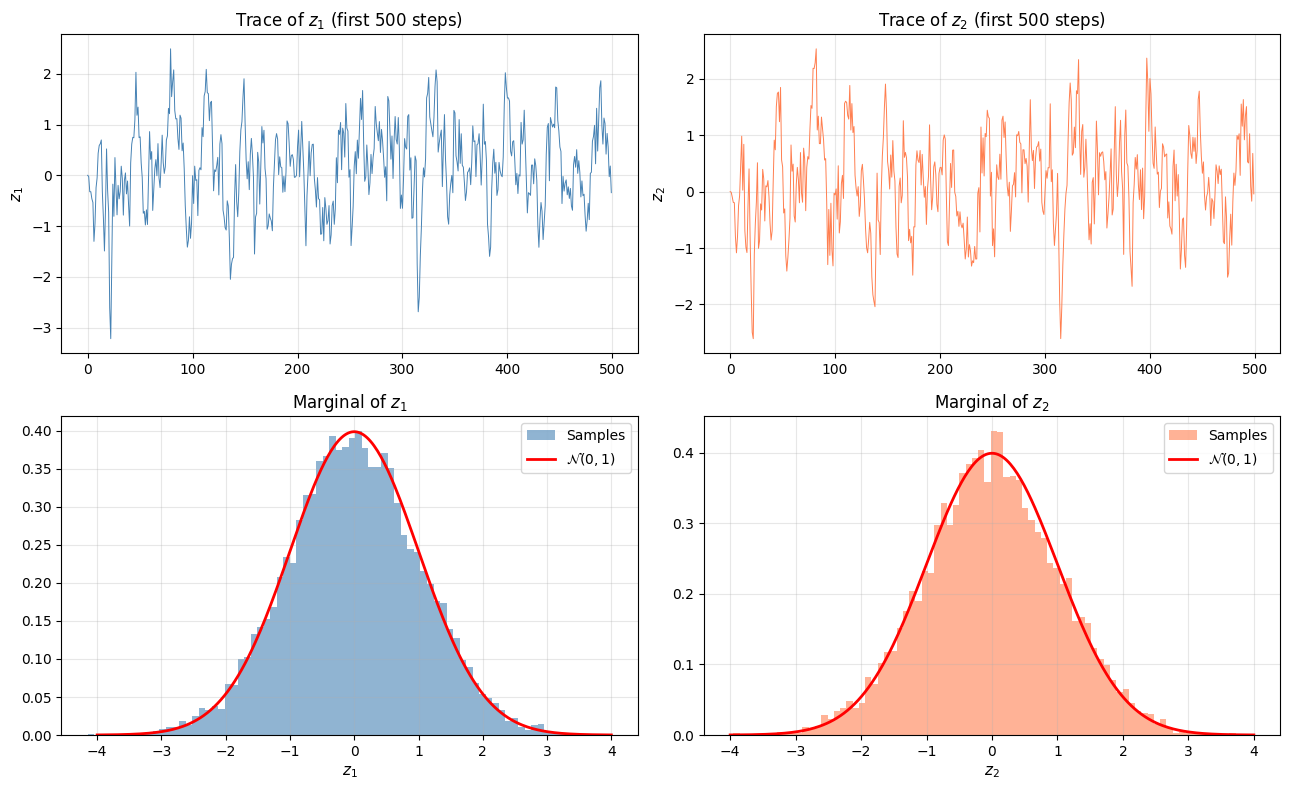

Sample mean z1: -0.0036  (true: 0)
Sample mean z2: -0.0008  (true: 0)
Sample var  z1: 1.0529  (true: 1)
Sample var  z2: 1.0494  (true: 1)
Sample corr:    0.9049  (true: 0.9)
Saved to images/gibbs_traces_and_marginals.png


In [2]:
# ── Figure 2: Trace plots showing one-variable-at-a-time updates ──
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Top-left: z1 trace (first 500 steps)
axes[0, 0].plot(z1[:500], lw=0.7, color='steelblue')
axes[0, 0].set_ylabel(r"$z_1$", fontsize=11)
axes[0, 0].set_title(r"Trace of $z_1$ (first 500 steps)", fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Top-right: z2 trace (first 500 steps)
axes[0, 1].plot(z2[:500], lw=0.7, color='coral')
axes[0, 1].set_ylabel(r"$z_2$", fontsize=11)
axes[0, 1].set_title(r"Trace of $z_2$ (first 500 steps)", fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: z1 marginal histogram vs N(0,1)
z_grid = np.linspace(-4, 4, 300)
axes[1, 0].hist(z1[burn_in:], bins=80, density=True, alpha=0.6, color='steelblue', label='Samples')
axes[1, 0].plot(z_grid, (1/np.sqrt(2*np.pi))*np.exp(-0.5*z_grid**2), 'r', lw=2, label=r'$\mathcal{N}(0,1)$')
axes[1, 0].set_xlabel(r"$z_1$", fontsize=11)
axes[1, 0].set_title(r"Marginal of $z_1$", fontsize=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: z2 marginal histogram vs N(0,1)
axes[1, 1].hist(z2[burn_in:], bins=80, density=True, alpha=0.6, color='coral', label='Samples')
axes[1, 1].plot(z_grid, (1/np.sqrt(2*np.pi))*np.exp(-0.5*z_grid**2), 'r', lw=2, label=r'$\mathcal{N}(0,1)$')
axes[1, 1].set_xlabel(r"$z_2$", fontsize=11)
axes[1, 1].set_title(r"Marginal of $z_2$", fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/gibbs_traces_and_marginals.png", dpi=150, bbox_inches='tight')
plt.show()

# Compute sample statistics
print(f"Sample mean z1: {np.mean(z1[burn_in:]):.4f}  (true: 0)")
print(f"Sample mean z2: {np.mean(z2[burn_in:]):.4f}  (true: 0)")
print(f"Sample var  z1: {np.var(z1[burn_in:]):.4f}  (true: 1)")
print(f"Sample var  z2: {np.var(z2[burn_in:]):.4f}  (true: 1)")
print(f"Sample corr:    {np.corrcoef(z1[burn_in:], z2[burn_in:])[0,1]:.4f}  (true: {rho})")
print("Saved to images/gibbs_traces_and_marginals.png")

## 5. Metropolis-within-Gibbs

When some conditional distributions are **not available in closed form**, pure Gibbs sampling is impossible. The solution: use **Gibbs** for the tractable conditionals and a **Metropolis–Hastings** step for the intractable ones. This hybrid is called **Metropolis-within-Gibbs**.

### Target Distribution

The joint log-density is:

$$\log p(z_1, z_2) = -\tfrac{1}{2}z_1^2 - \frac{(z_2 - z_1^2)^2}{0.2}$$

This produces a **banana-shaped** (non-Gaussian) density:
- **$z_2 \mid z_1$** is Gaussian: $\mathcal{N}(z_1^2,\, 0.1)$ — **tractable** → Gibbs step.
- **$z_1 \mid z_2$** has no simple closed form — **intractable** → Metropolis step.

### Algorithm (each iteration)

1. **Gibbs step** for $z_2$: draw $z_2^{(t)} \sim \mathcal{N}\bigl((z_1^{(t-1)})^2,\; 0.1\bigr)$ — exact.
2. **Metropolis step** for $z_1$:
   - Propose $z_1^* = z_1^{(t-1)} + \epsilon$, $\epsilon \sim \mathcal{N}(0, 0.09)$.
   - Accept with probability $\min\bigl(1,\; e^{\log p(z_1^*, z_2^{(t)}) - \log p(z_1^{(t-1)}, z_2^{(t)})}\bigr)$.

### Parameters

| Parameter | Value |
|---|---|
| Samples | 150,000 |
| Burn-in | 5,000 |
| MH proposal std | 0.3 |

### Why This Matters
- Many real-world models (e.g. Bayesian neural networks, hierarchical models) have **some** conditionals that are conjugate and **others** that are not. Metropolis-within-Gibbs handles both naturally.
- The banana shape is a classic test case — its curvature makes it challenging for standard random-walk MH alone.

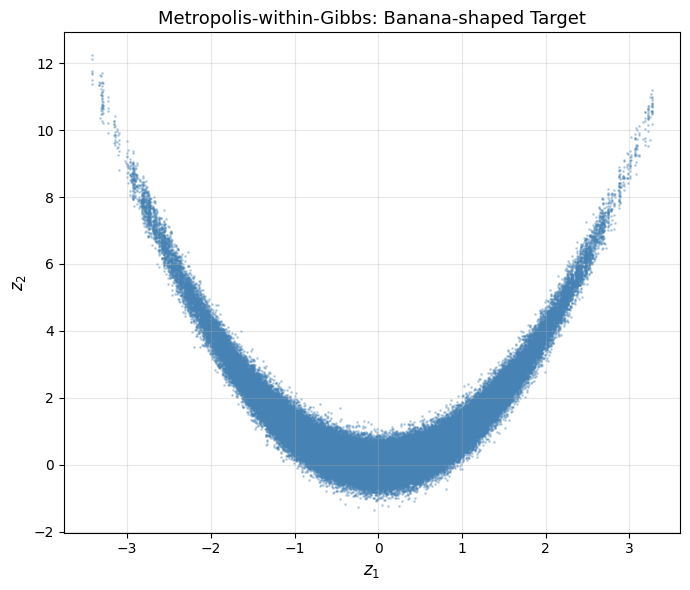

MH acceptance rate (z1 step): 0.6358
Sample mean z1: 0.0024
Sample mean z2: 0.9744
Sample std  z1: 0.9870
Sample std  z2: 1.4035
Saved to images/mwg_banana_scatter.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def log_p(z1, z2):
    return -0.5*z1**2 - 0.5*((z2 - z1**2)**2)/0.1

n_samples = 150000

z1 = np.zeros(n_samples)
z2 = np.zeros(n_samples)

# initialization
z1[0], z2[0] = 0.0, 0.0

proposal_std = 0.3
n_accept = 0

for t in range(1, n_samples):

    # ---- Gibbs step for z2 | z1 (exact conditional)
    z2[t] = np.random.normal(z1[t-1]**2, np.sqrt(0.1))

    # ---- Metropolis step for z1 | z2 (intractable conditional)
    z1_prop = z1[t-1] + np.random.normal(0, proposal_std)

    log_alpha = (
        log_p(z1_prop, z2[t]) -
        log_p(z1[t-1], z2[t])
    )

    if np.log(np.random.rand()) < log_alpha:
        z1[t] = z1_prop
        n_accept += 1
    else:
        z1[t] = z1[t-1]

burn_in = 5000
accept_rate = n_accept / (n_samples - 1)

# ── Figure 1: Joint scatter plot (banana shape) ──
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z1[burn_in:], z2[burn_in:], s=1, alpha=0.3, color='steelblue')
ax.set_xlabel(r"$z_1$", fontsize=12)
ax.set_ylabel(r"$z_2$", fontsize=12)
ax.set_title(r"Metropolis-within-Gibbs: Banana-shaped Target", fontsize=13)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("images/mwg_banana_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"MH acceptance rate (z1 step): {accept_rate:.4f}")
print(f"Sample mean z1: {np.mean(z1[burn_in:]):.4f}")
print(f"Sample mean z2: {np.mean(z2[burn_in:]):.4f}")
print(f"Sample std  z1: {np.std(z1[burn_in:]):.4f}")
print(f"Sample std  z2: {np.std(z2[burn_in:]):.4f}")
print("Saved to images/mwg_banana_scatter.png")

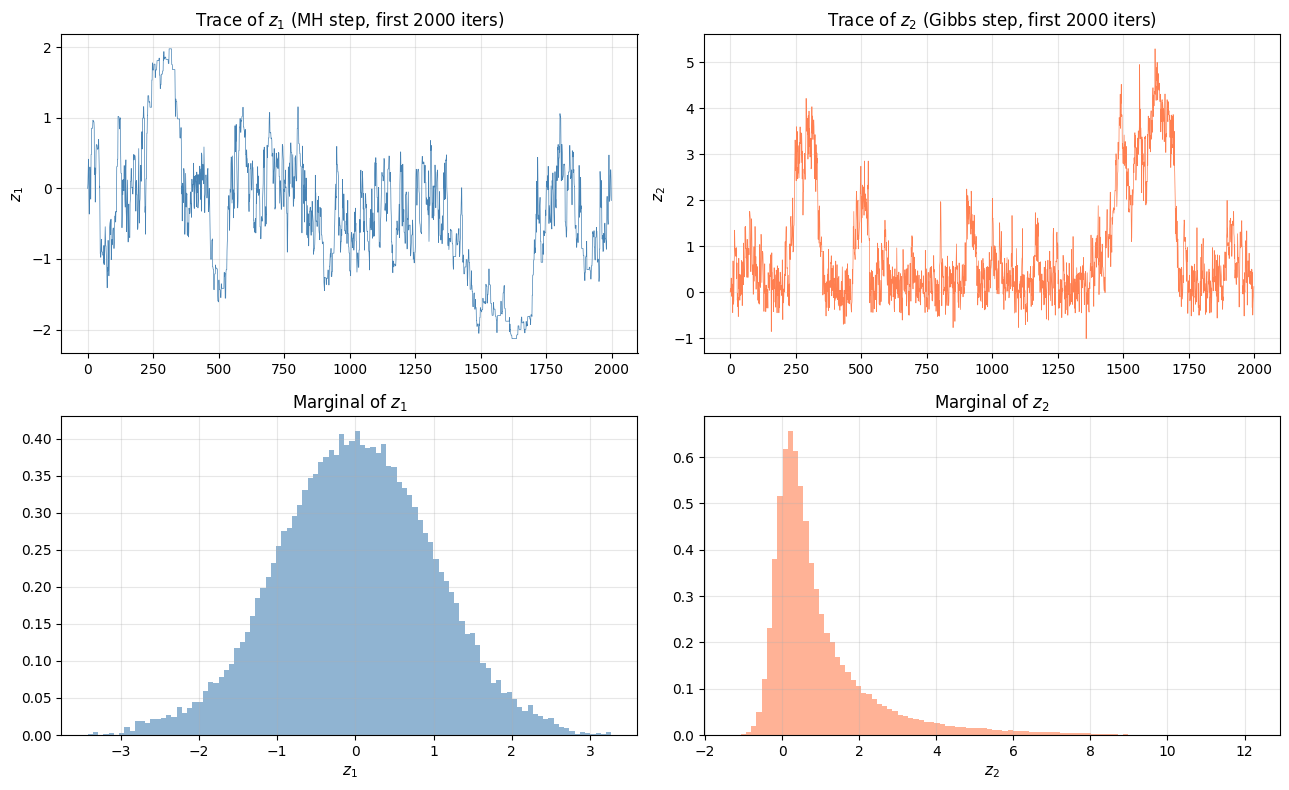

Saved to images/mwg_traces_and_marginals.png


In [2]:
# ── Figure 2: Trace plots + marginal histograms ──
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Top-left: z1 trace (first 2000 steps) — shows MH random walk
axes[0, 0].plot(z1[:2000], lw=0.5, color='steelblue')
axes[0, 0].set_ylabel(r"$z_1$", fontsize=11)
axes[0, 0].set_title(r"Trace of $z_1$ (MH step, first 2000 iters)", fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Top-right: z2 trace (first 2000 steps) — shows exact Gibbs draws
axes[0, 1].plot(z2[:2000], lw=0.5, color='coral')
axes[0, 1].set_ylabel(r"$z_2$", fontsize=11)
axes[0, 1].set_title(r"Trace of $z_2$ (Gibbs step, first 2000 iters)", fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: z1 marginal histogram
axes[1, 0].hist(z1[burn_in:], bins=100, density=True, alpha=0.6, color='steelblue')
axes[1, 0].set_xlabel(r"$z_1$", fontsize=11)
axes[1, 0].set_title(r"Marginal of $z_1$", fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: z2 marginal histogram
axes[1, 1].hist(z2[burn_in:], bins=100, density=True, alpha=0.6, color='coral')
axes[1, 1].set_xlabel(r"$z_2$", fontsize=11)
axes[1, 1].set_title(r"Marginal of $z_2$", fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/mwg_traces_and_marginals.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/mwg_traces_and_marginals.png")

## 6. Ancestral Sampling

**Ancestral Sampling** is the simplest sampling method for **directed graphical models** (Bayesian networks). It generates joint samples by following the topological order of the DAG — each variable is sampled from its conditional distribution given its already-sampled parents.

### Algorithm

For a directed model $p(z_1, z_2, z_3) = p(z_1)\,p(z_2 \mid z_1)\,p(z_3 \mid z_2)$:

1. Sample $z_1 \sim p(z_1)$
2. Sample $z_2 \sim p(z_2 \mid z_1)$
3. Sample $z_3 \sim p(z_3 \mid z_2)$

Each draw is **independent and exact** — no Markov chain, no burn-in, no accept/reject.

### Setup: Linear Gaussian Chain

$$z_1 \sim \mathcal{N}(0, 1), \qquad z_2 \mid z_1 \sim \mathcal{N}(a\,z_1,\; \sigma^2), \qquad z_3 \mid z_2 \sim \mathcal{N}(b\,z_2,\; \tau^2)$$

| Parameter | Value | Meaning |
|---|---|---|
| $a$ | 1.5 | Slope from $z_1$ to $z_2$ |
| $b$ | $-0.8$ | Slope from $z_2$ to $z_3$ |
| $\sigma$ | 0.5 | Noise std for $z_2$ |
| $\tau$ | 0.3 | Noise std for $z_3$ |
| $N$ | 10,000 | Number of independent samples |

### Key Observations

- **Fast and unbiased**: Every sample is i.i.d. from the true joint — no convergence issues.
- **Only works forward**: Ancestral sampling requires the model to be a DAG and all conditionals to be tractable. It **cannot** incorporate observed evidence (conditioning) efficiently — for that, use MCMC or variational methods.
- The scatter plot of $(z_1, z_2)$ shows a strong positive linear relationship (slope $\approx a = 1.5$) with Gaussian noise.

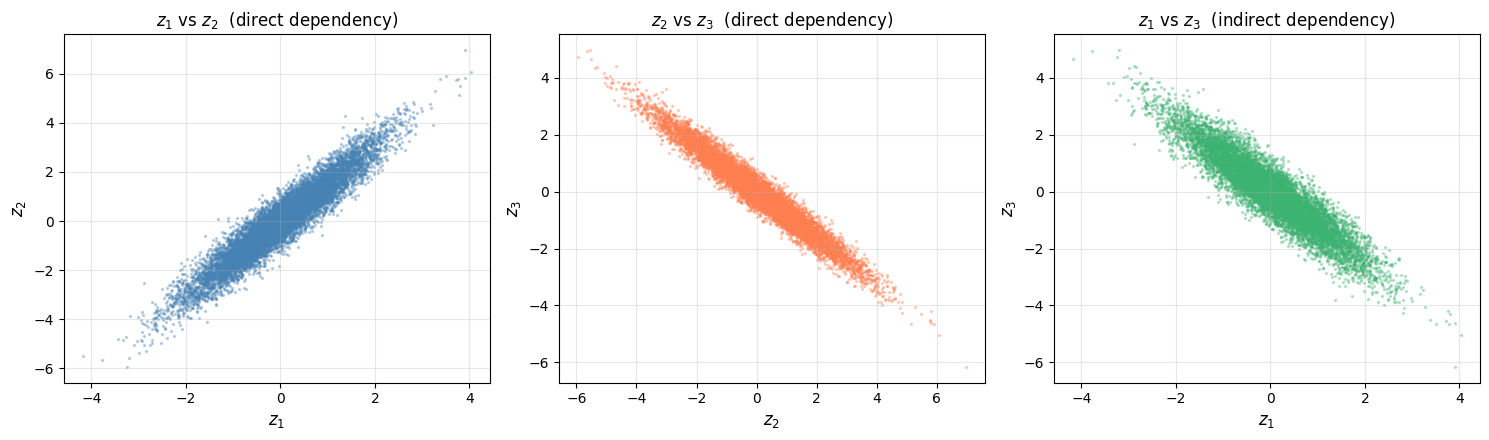

Mean z1: 0.0116  (true: 0)
Mean z2: 0.0207  (true: 0)
Mean z3: -0.0176  (true: 0)
Std  z1: 1.0072  (true: 1.0)
Std  z2: 1.5894  (true: 1.5811)
Std  z3: 1.3030  (true: 1.3000)
Corr(z1,z2): 0.9492
Corr(z2,z3): -0.9736
Corr(z1,z3): -0.9239
Saved to images/ancestral_pairwise_scatter.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the linear Gaussian chain: z1 → z2 → z3
a = 1.5       # slope z1 -> z2
b = -0.8      # slope z2 -> z3
sigma = 0.5   # noise std for z2 | z1
tau = 0.3     # noise std for z3 | z2

def ancestral_sample():
    z1 = np.random.normal(0, 1)             # p(z1)
    z2 = np.random.normal(a * z1, sigma)     # p(z2 | z1)
    z3 = np.random.normal(b * z2, tau)       # p(z3 | z2)
    return z1, z2, z3

# Generate samples
N = 10000
samples = np.array([ancestral_sample() for _ in range(N)])
z1, z2, z3 = samples.T

# ── Figure 1: Pairwise scatter plots ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(z1, z2, s=2, alpha=0.3, color='steelblue')
axes[0].set_xlabel(r"$z_1$", fontsize=12)
axes[0].set_ylabel(r"$z_2$", fontsize=12)
axes[0].set_title(r"$z_1$ vs $z_2$  (direct dependency)", fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(z2, z3, s=2, alpha=0.3, color='coral')
axes[1].set_xlabel(r"$z_2$", fontsize=12)
axes[1].set_ylabel(r"$z_3$", fontsize=12)
axes[1].set_title(r"$z_2$ vs $z_3$  (direct dependency)", fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].scatter(z1, z3, s=2, alpha=0.3, color='mediumseagreen')
axes[2].set_xlabel(r"$z_1$", fontsize=12)
axes[2].set_ylabel(r"$z_3$", fontsize=12)
axes[2].set_title(r"$z_1$ vs $z_3$  (indirect dependency)", fontsize=12)
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/ancestral_pairwise_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print(f"Mean z1: {np.mean(z1):.4f}  (true: 0)")
print(f"Mean z2: {np.mean(z2):.4f}  (true: 0)")
print(f"Mean z3: {np.mean(z3):.4f}  (true: 0)")
print(f"Std  z1: {np.std(z1):.4f}  (true: 1.0)")
print(f"Std  z2: {np.std(z2):.4f}  (true: {np.sqrt(a**2 + sigma**2):.4f})")
print(f"Std  z3: {np.std(z3):.4f}  (true: {np.sqrt(b**2*(a**2 + sigma**2) + tau**2):.4f})")
print(f"Corr(z1,z2): {np.corrcoef(z1,z2)[0,1]:.4f}")
print(f"Corr(z2,z3): {np.corrcoef(z2,z3)[0,1]:.4f}")
print(f"Corr(z1,z3): {np.corrcoef(z1,z3)[0,1]:.4f}")
print("Saved to images/ancestral_pairwise_scatter.png")

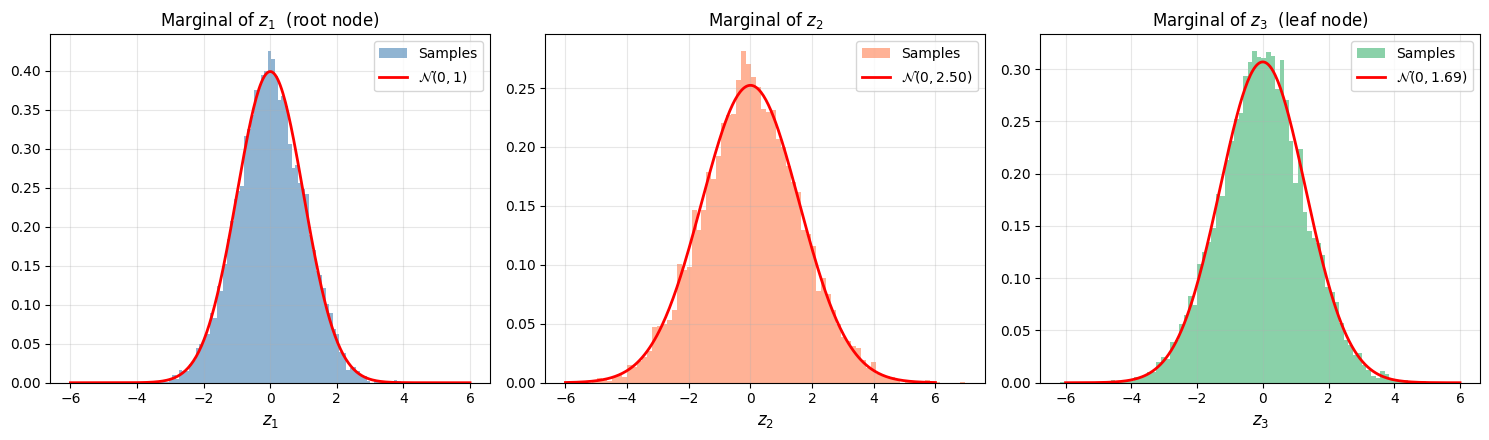

Saved to images/ancestral_marginal_histograms.png


In [2]:
# ── Figure 2: Marginal histograms with true densities ──
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# True marginal parameters
# z1 ~ N(0, 1)
# z2 ~ N(0, a^2 + sigma^2)
# z3 ~ N(0, b^2*(a^2 + sigma^2) + tau^2)
std_z2_true = np.sqrt(a**2 + sigma**2)
std_z3_true = np.sqrt(b**2*(a**2 + sigma**2) + tau**2)

z_grid = np.linspace(-6, 6, 300)

axes[0].hist(z1, bins=80, density=True, alpha=0.6, color='steelblue', label='Samples')
axes[0].plot(z_grid, norm.pdf(z_grid, 0, 1), 'r', lw=2, label=r'$\mathcal{N}(0, 1)$')
axes[0].set_xlabel(r"$z_1$", fontsize=12)
axes[0].set_title(r"Marginal of $z_1$  (root node)", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].hist(z2, bins=80, density=True, alpha=0.6, color='coral', label='Samples')
axes[1].plot(z_grid, norm.pdf(z_grid, 0, std_z2_true), 'r', lw=2,
             label=rf'$\mathcal{{N}}(0, {std_z2_true**2:.2f})$')
axes[1].set_xlabel(r"$z_2$", fontsize=12)
axes[1].set_title(r"Marginal of $z_2$", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

axes[2].hist(z3, bins=80, density=True, alpha=0.6, color='mediumseagreen', label='Samples')
axes[2].plot(z_grid, norm.pdf(z_grid, 0, std_z3_true), 'r', lw=2,
             label=rf'$\mathcal{{N}}(0, {std_z3_true**2:.2f})$')
axes[2].set_xlabel(r"$z_3$", fontsize=12)
axes[2].set_title(r"Marginal of $z_3$  (leaf node)", fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/ancestral_marginal_histograms.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/ancestral_marginal_histograms.png")

## 7. Langevin Dynamics (Unadjusted Langevin Algorithm)

**Langevin Dynamics** uses gradient information from the target density to guide sampling, making it especially effective for continuous distributions where $\nabla \log p(x)$ is available.

### Idea

Instead of a blind random-walk proposal, we follow the **gradient of the log-density** (the *score function*) plus Gaussian noise. The discrete-time update rule is derived from the Langevin stochastic differential equation:

$$x_{t+1} = x_t - \eta\,\nabla E(x_t) + \sqrt{2\eta}\;\xi_t, \qquad \xi_t \sim \mathcal{N}(0, 1)$$

where $E(x)$ is the **energy function** and the target density is:

$$p(x) \propto \exp\bigl(-E(x)\bigr)$$

### Target: Double-Well Potential

$$E(x) = \tfrac{1}{4}x^4 - \tfrac{1}{2}x^2, \qquad \nabla E(x) = x^3 - x$$

This creates a **bimodal** target density with modes near $x = \pm 1$ (the two minima of $E$), separated by an energy barrier at $x = 0$.

### Parameters

| Parameter | Value | Purpose |
|---|---|---|
| Step size $\eta$ | 0.04 | Discretization granularity |
| Chain length $T$ | 500,000 | Total iterations |
| Initial point $x_0$ | 3.0 | Starting position (far from both modes) |
| Burn-in | 1,000 | Samples discarded before histogram |

### Key Observations

- **Gradient-guided**: Unlike MH, the proposal is *informed* by the geometry of the target — it drifts toward high-density regions, leading to higher acceptance and faster mixing.
- **No accept/reject step**: This is the *unadjusted* variant (ULA). The discretization introduces a small bias that vanishes as $\eta \to 0$. Adding a Metropolis correction yields **MALA** (Metropolis-Adjusted Langevin Algorithm).
- **Mode-hopping**: With a double-well potential the chain must cross an energy barrier. A long chain and appropriate $\eta$ ensure both modes are visited.

### Limitations
- **Discretization bias**: For finite $\eta$, ULA's stationary distribution only *approximates* the target.
- **Step-size sensitivity**: Too large → instability; too small → slow mixing.
- **Multi-modal targets**: Mixing between well-separated modes can still be slow; tempering or replica-exchange methods can help.

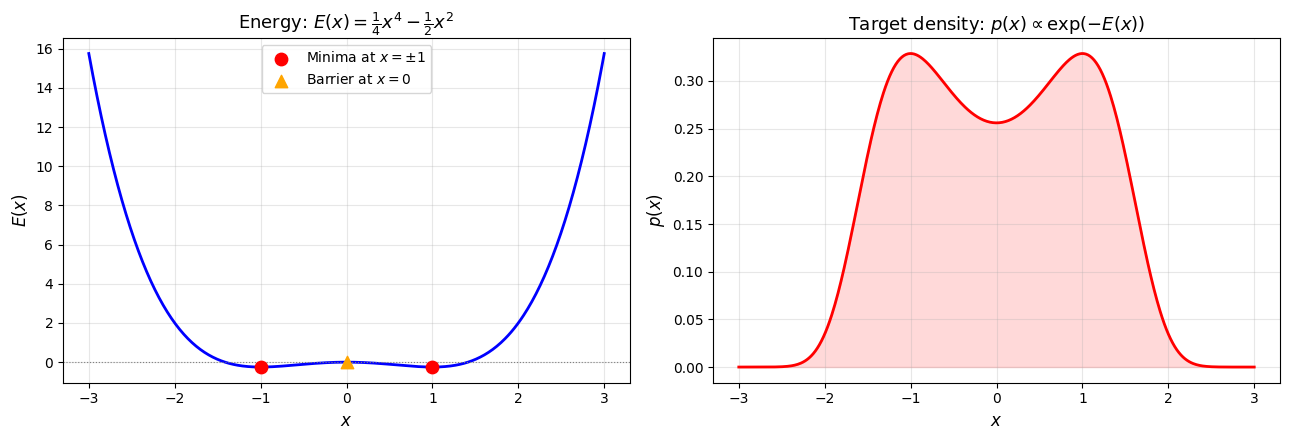

Saved to images/langevin_energy_and_density.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── Energy function and its gradient ──
def energy(x):
    return 0.25*x**4 - 0.5*x**2  # double-well potential

def grad_energy(x):
    return x**3 - x               # score: -grad_energy = -(x^3 - x)

# ── Langevin dynamics parameters ──
eta = 0.04       # step size
T = 500000       # total iterations
x = 3.0          # initial point (far from modes)
burn_in = 1000

samples = np.zeros(T)
for t in range(T):
    noise = np.sqrt(2*eta) * np.random.randn()
    x = x - eta * grad_energy(x) + noise
    samples[t] = x

# ── Figure 1: Energy function + Target density (side by side) ──
xs = np.linspace(-3, 3, 500)
Es = energy(xs)
p_vals = np.exp(-Es)
p_vals /= np.trapezoid(p_vals, xs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Energy landscape
axes[0].plot(xs, Es, 'b', lw=2)
axes[0].axhline(0, color='gray', ls=':', lw=0.8)
axes[0].scatter([-1, 1], [energy(-1), energy(1)], color='red', s=80, zorder=5,
                label=r'Minima at $x = \pm 1$')
axes[0].scatter([0], [energy(0)], color='orange', s=80, zorder=5, marker='^',
                label=r'Barrier at $x = 0$')
axes[0].set_xlabel(r"$x$", fontsize=12)
axes[0].set_ylabel(r"$E(x)$", fontsize=12)
axes[0].set_title(r"Energy: $E(x) = \frac{1}{4}x^4 - \frac{1}{2}x^2$", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Target density
axes[1].plot(xs, p_vals, 'r', lw=2)
axes[1].fill_between(xs, p_vals, alpha=0.15, color='red')
axes[1].set_xlabel(r"$x$", fontsize=12)
axes[1].set_ylabel(r"$p(x)$", fontsize=12)
axes[1].set_title(r"Target density: $p(x) \propto \exp(-E(x))$", fontsize=13)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/langevin_energy_and_density.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/langevin_energy_and_density.png")

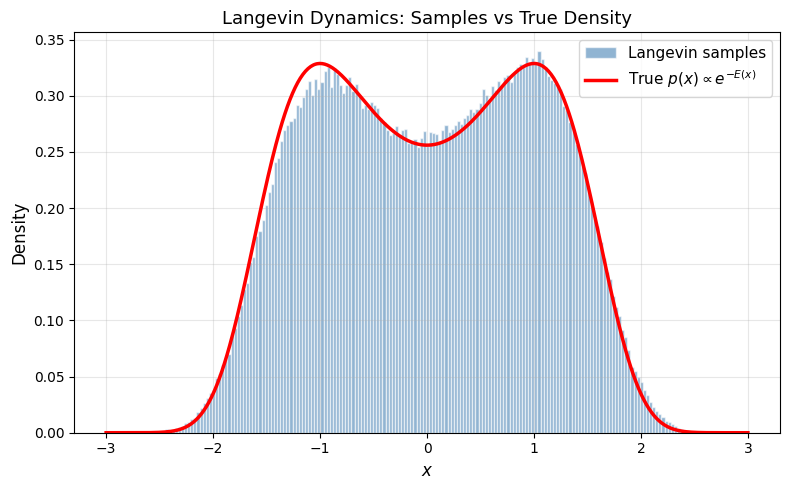

Sample mean:  0.0264  (true: 0)
Sample std:   1.0236
Sample E[x^2]: 1.0485
Saved to images/langevin_samples_vs_density.png


In [4]:
# ── Figure 2: Sample histogram overlaid with true density ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(samples[burn_in:], bins=200, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='Langevin samples')
ax.plot(xs, p_vals, 'r', lw=2.5, label=r'True $p(x) \propto e^{-E(x)}$')
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Langevin Dynamics: Samples vs True Density", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("images/langevin_samples_vs_density.png", dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
samples_eff = samples[burn_in:]
print(f"Sample mean:  {np.mean(samples_eff):.4f}  (true: 0)")
print(f"Sample std:   {np.std(samples_eff):.4f}")
print(f"Sample E[x^2]: {np.mean(samples_eff**2):.4f}")
print("Saved to images/langevin_samples_vs_density.png")

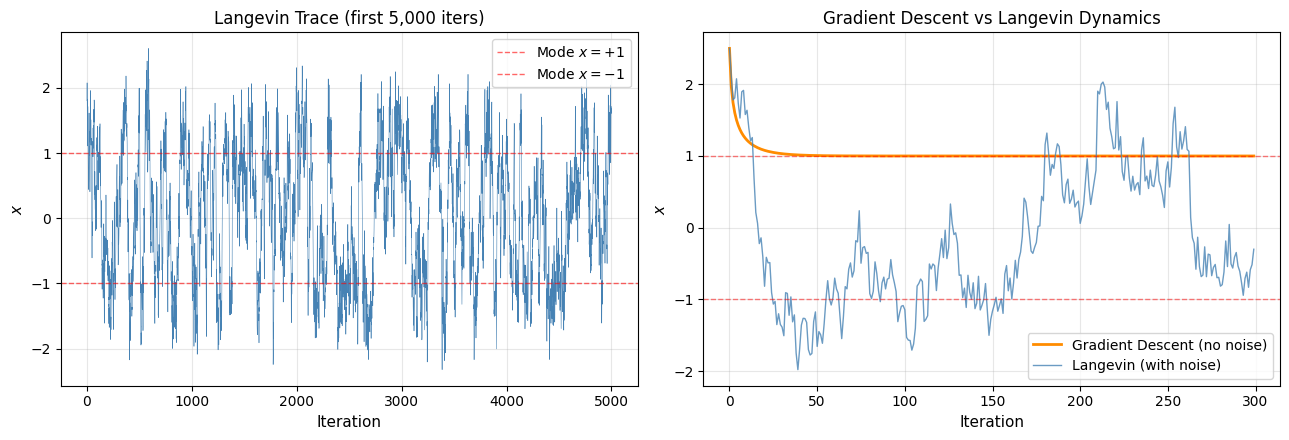

Saved to images/langevin_trace_and_gd_comparison.png


In [5]:
# ── Figure 3: Trace plot + Gradient Descent vs Langevin comparison ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: Langevin trace plot (first 5000 steps)
axes[0].plot(samples[:5000], lw=0.4, color='steelblue')
axes[0].axhline(1, color='red', ls='--', lw=1, alpha=0.6, label=r'Mode $x=+1$')
axes[0].axhline(-1, color='red', ls='--', lw=1, alpha=0.6, label=r'Mode $x=-1$')
axes[0].set_xlabel("Iteration", fontsize=11)
axes[0].set_ylabel(r"$x$", fontsize=11)
axes[0].set_title("Langevin Trace (first 5,000 iters)", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: Gradient descent (no noise) vs Langevin (with noise)
# GD trajectory: x_{t+1} = x_t - eta * grad E(x_t)
gd_steps = 300
x_gd = np.zeros(gd_steps)
x_gd[0] = 2.5
for t in range(1, gd_steps):
    x_gd[t] = x_gd[t-1] - eta * grad_energy(x_gd[t-1])

# Langevin trajectory (same init)
x_lang = np.zeros(gd_steps)
x_lang[0] = 2.5
np.random.seed(42)
for t in range(1, gd_steps):
    x_lang[t] = x_lang[t-1] - eta * grad_energy(x_lang[t-1]) + np.sqrt(2*eta) * np.random.randn()

axes[1].plot(x_gd, lw=2, color='darkorange', label='Gradient Descent (no noise)')
axes[1].plot(x_lang, lw=1, color='steelblue', alpha=0.8, label='Langevin (with noise)')
axes[1].axhline(1, color='red', ls='--', lw=1, alpha=0.5)
axes[1].axhline(-1, color='red', ls='--', lw=1, alpha=0.5)
axes[1].set_xlabel("Iteration", fontsize=11)
axes[1].set_ylabel(r"$x$", fontsize=11)
axes[1].set_title("Gradient Descent vs Langevin Dynamics", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("images/langevin_trace_and_gd_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to images/langevin_trace_and_gd_comparison.png")

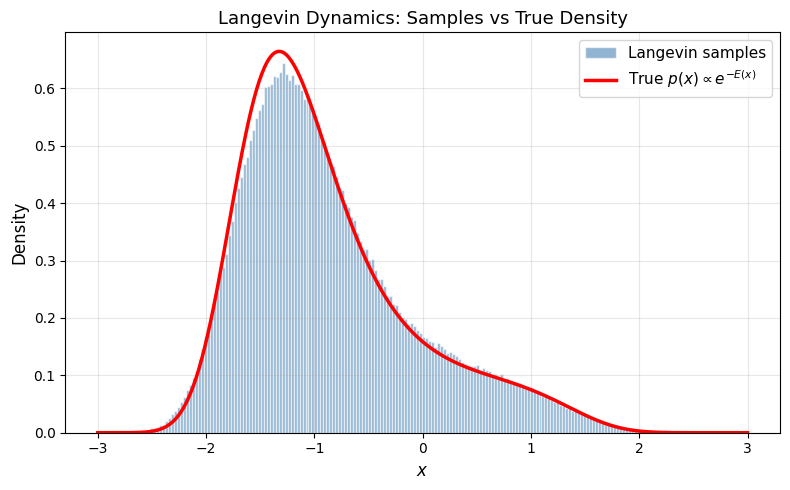

In [ ]:
# testing the langevin sampler (1-D) — energy arg removed
from disSamplePackage import sampler
import numpy as np
import matplotlib.pyplot as plt

sam = sampler()
energy = lambda x: 0.25*x**4 - 0.5*x**2 + x
grad_energy = lambda x: x**3 - x + 1

samples = sam.LangevinSampling(grad_energy, eta=0.04, n_samples=500000, x_range=(-3, 3))

# testing the sample histogram
xs = np.linspace(-3, 3, 500)
Es = energy(xs)
p_vals = np.exp(-Es)
p_vals /= np.trapezoid(p_vals, xs)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(samples[1000:], bins=200, density=True, alpha=0.6, color='steelblue',
        edgecolor='white', label='Langevin samples')
ax.plot(xs, p_vals, 'r', lw=2.5, label=r'True $p(x) \propto e^{-E(x)}$')
ax.set_xlabel(r"$x$", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Langevin Dynamics (1-D Test): Samples vs True Density", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()

## 8. Testing Multidimensional Langevin Sampling

### 2-D Test: Correlated Bivariate Gaussian

The energy function for a bivariate Gaussian $\mathcal{N}(\mathbf{0}, \Sigma)$ with precision matrix $\Lambda = \Sigma^{-1}$ is:

$$E(\mathbf{x}) = \tfrac{1}{2}\,\mathbf{x}^\top \Lambda\, \mathbf{x}$$

$$\nabla E(\mathbf{x}) = \Lambda\, \mathbf{x}$$

We use $\Sigma = \begin{pmatrix} 1 & 0.8 \\ 0.8 & 1 \end{pmatrix}$ so that $\Lambda = \Sigma^{-1} = \begin{pmatrix} 2.778 & -2.222 \\ -2.222 & 2.778 \end{pmatrix}$.

In [ ]:
# ── 2-D Langevin Test: Correlated Bivariate Gaussian ──
import numpy as np
import matplotlib.pyplot as plt
from disSamplePackage import sampler

# Target: N(0, Sigma) with Sigma = [[1, 0.8], [0.8, 1]]
Sigma = np.array([[1.0, 0.8],
                  [0.8, 1.0]])
Lambda = np.linalg.inv(Sigma)   # precision matrix

def grad_energy_2d(x):
    return Lambda @ x             # ∇E = Λx

sam = sampler()
samples_2d = sam.LangevinSampling(
    grad_energy=grad_energy_2d,
    eta=0.01,
    n_samples=200_000,
    x_range=np.array([[-4, 4],
                      [-4, 4]])
)

burn_in = 2000
s = samples_2d[burn_in:]

# ── Visualization: scatter + marginal histograms ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: Joint scatter
axes[0].scatter(s[:, 0], s[:, 1], s=1, alpha=0.15, color='steelblue')
# True 2-sigma ellipse
theta = np.linspace(0, 2*np.pi, 200)
eigvals, eigvecs = np.linalg.eigh(Sigma)
ell = (eigvecs @ np.diag(np.sqrt(eigvals)) @ np.array([np.cos(theta), np.sin(theta)])) * 2
axes[0].plot(ell[0], ell[1], 'r-', lw=2, label=r'True $2\sigma$ ellipse')
axes[0].set_xlabel(r"$x_1$", fontsize=12)
axes[0].set_ylabel(r"$x_2$", fontsize=12)
axes[0].set_title("2-D Langevin: Joint Scatter", fontsize=13)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Center: x1 marginal
z_grid = np.linspace(-4, 4, 300)
true_pdf = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*z_grid**2)
axes[1].hist(s[:, 0], bins=100, density=True, alpha=0.6, color='steelblue', label='Samples')
axes[1].plot(z_grid, true_pdf, 'r', lw=2, label=r'$\mathcal{N}(0,1)$')
axes[1].set_xlabel(r"$x_1$", fontsize=12)
axes[1].set_title(r"Marginal of $x_1$", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Right: x2 marginal
axes[2].hist(s[:, 1], bins=100, density=True, alpha=0.6, color='coral', label='Samples')
axes[2].plot(z_grid, true_pdf, 'r', lw=2, label=r'$\mathcal{N}(0,1)$')
axes[2].set_xlabel(r"$x_2$", fontsize=12)
axes[2].set_title(r"Marginal of $x_2$", fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Statistics
print(f"Sample mean:       [{np.mean(s[:,0]):.4f}, {np.mean(s[:,1]):.4f}]  (true: [0, 0])")
print(f"Sample std:        [{np.std(s[:,0]):.4f}, {np.std(s[:,1]):.4f}]  (true: [1, 1])")
print(f"Sample correlation: {np.corrcoef(s[:,0], s[:,1])[0,1]:.4f}  (true: 0.8)")

### 3-D Test: Trivariate Gaussian

For a 3-D target we cannot directly visualize the joint scatter. Instead we verify correctness by comparing:

1. **Pairwise 2-D scatter plots** — project onto each pair $(x_i, x_j)$.
2. **Marginal histograms** — each $x_i$ should match $\mathcal{N}(0, \Sigma_{ii})$.
3. **Sample covariance matrix** — should converge to the true $\Sigma$.

Target: $\mathcal{N}(\mathbf{0}, \Sigma)$ with $\Sigma = \begin{pmatrix} 1 & 0.5 & 0.3 \\ 0.5 & 1 & -0.4 \\ 0.3 & -0.4 & 1 \end{pmatrix}$

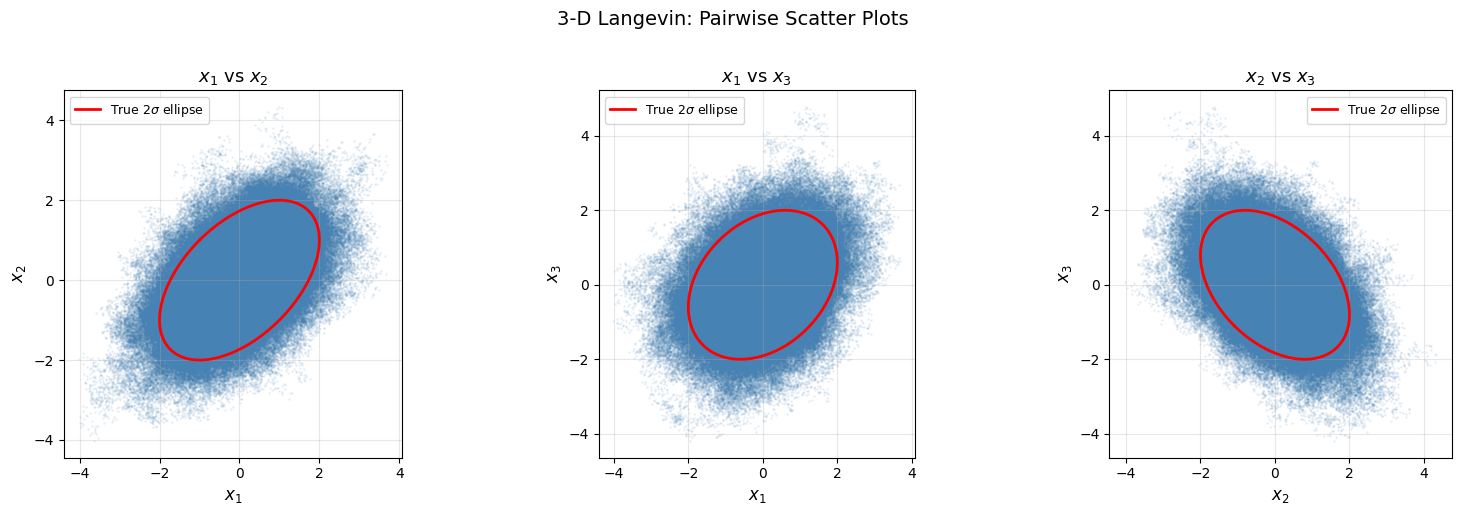

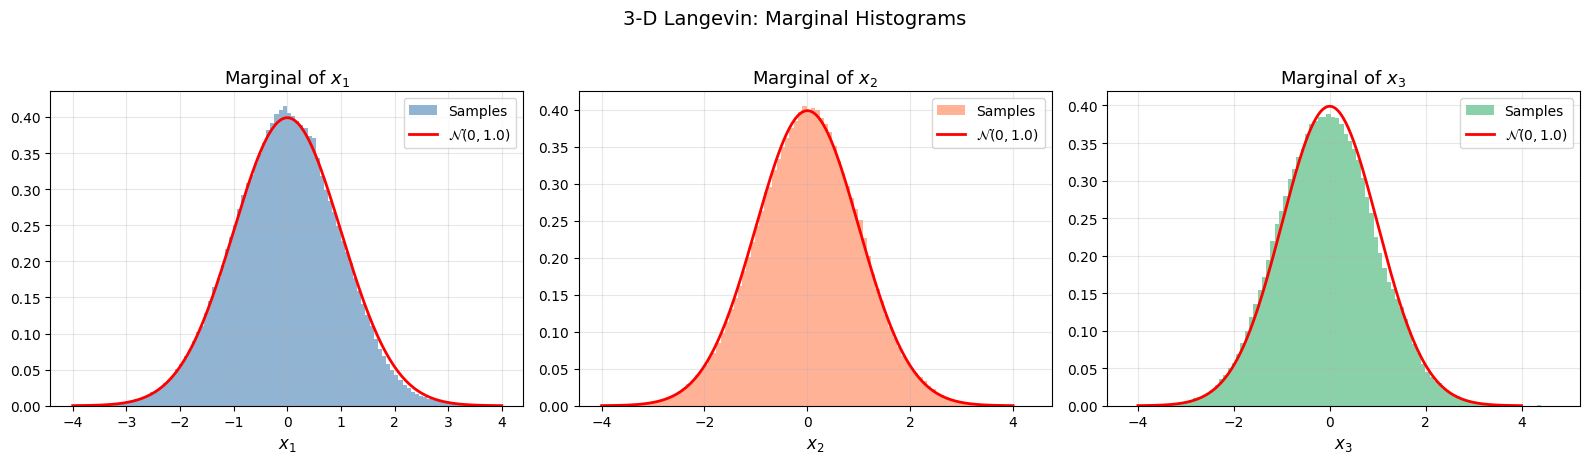

True covariance matrix:
[[ 1.   0.5  0.3]
 [ 0.5  1.  -0.4]
 [ 0.3 -0.4  1. ]]

Sample covariance matrix:
[[ 0.9643  0.4601  0.2994]
 [ 0.4601  0.9905 -0.4339]
 [ 0.2994 -0.4339  1.0327]]

Max absolute error: 0.0399


In [1]:
# ── 3-D Langevin Test: Trivariate Gaussian ──
import numpy as np
import matplotlib.pyplot as plt
from disSamplePackage import sampler

# Target: N(0, Sigma_3d)
Sigma_3d = np.array([[1.0,  0.5,  0.3],
                     [0.5,  1.0, -0.4],
                     [0.3, -0.4,  1.0]])
Lambda_3d = np.linalg.inv(Sigma_3d)

def grad_energy_3d(x):
    return Lambda_3d @ x

sam = sampler()
samples_3d = sam.LangevinSampling(
    grad_energy=grad_energy_3d,
    eta=0.005,
    n_samples=500_000,
    x_range=np.array([[-4, 4],
                      [-4, 4],
                      [-4, 4]])
)

burn_in = 5000
s3 = samples_3d[burn_in:]

# ── Method 1: Pairwise scatter plots ──
labels = [r"$x_1$", r"$x_2$", r"$x_3$"]
pairs = [(0, 1), (0, 2), (1, 2)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (i, j) in zip(axes, pairs):
    ax.scatter(s3[:, i], s3[:, j], s=1, alpha=0.08, color='steelblue')
    # True 2-sigma ellipse for the (i,j) marginal
    Sigma_ij = Sigma_3d[np.ix_([i, j], [i, j])]
    eigvals, eigvecs = np.linalg.eigh(Sigma_ij)
    theta = np.linspace(0, 2*np.pi, 200)
    ell = (eigvecs @ np.diag(np.sqrt(eigvals)) @ np.array([np.cos(theta), np.sin(theta)])) * 2
    ax.plot(ell[0], ell[1], 'r-', lw=2, label=r'True $2\sigma$ ellipse')
    ax.set_xlabel(labels[i], fontsize=12)
    ax.set_ylabel(labels[j], fontsize=12)
    ax.set_title(f"{labels[i]} vs {labels[j]}", fontsize=13)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("3-D Langevin: Pairwise Scatter Plots", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# ── Method 2: Marginal histograms ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
z_grid = np.linspace(-4, 4, 300)
for k in range(3):
    std_k = np.sqrt(Sigma_3d[k, k])
    true_pdf = (1/(np.sqrt(2*np.pi)*std_k)) * np.exp(-0.5*(z_grid/std_k)**2)
    axes[k].hist(s3[:, k], bins=100, density=True, alpha=0.6,
                 color=['steelblue','coral','mediumseagreen'][k], label='Samples')
    axes[k].plot(z_grid, true_pdf, 'r', lw=2,
                 label=rf'$\mathcal{{N}}(0, {Sigma_3d[k,k]:.1f})$')
    axes[k].set_xlabel(labels[k], fontsize=12)
    axes[k].set_title(f"Marginal of {labels[k]}", fontsize=13)
    axes[k].legend(fontsize=10)
    axes[k].grid(True, alpha=0.3)

fig.suptitle("3-D Langevin: Marginal Histograms", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# ── Method 3: Compare sample covariance to true Sigma ──
sample_cov = np.cov(s3.T)
print("True covariance matrix:")
print(Sigma_3d)
print("\nSample covariance matrix:")
print(np.round(sample_cov, 4))
print(f"\nMax absolute error: {np.max(np.abs(sample_cov - Sigma_3d)):.4f}")